<a href="https://colab.research.google.com/github/Innovatewithapple/DBSCAN/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
df = pd.read_csv('/content/store_customers.csv')
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
539,1539,M,30.0,31.9,42.0
342,1342,M,37.0,52.0,49.0
488,1488,M,48.0,82.5,30.0
602,1602,M,42.0,69.6,52.0
430,1430,M,26.0,31.4,59.0


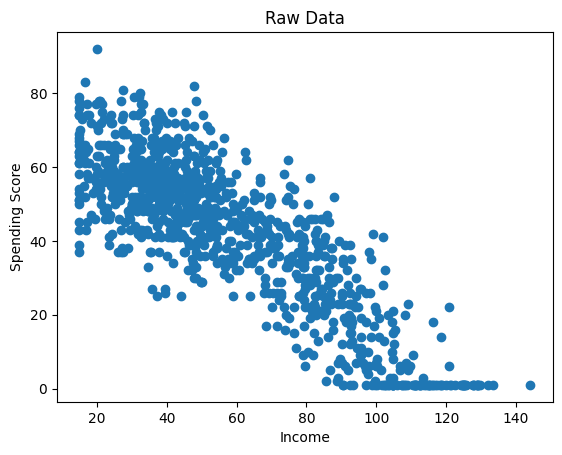

In [4]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Raw Data')
plt.show()

In [5]:
x = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

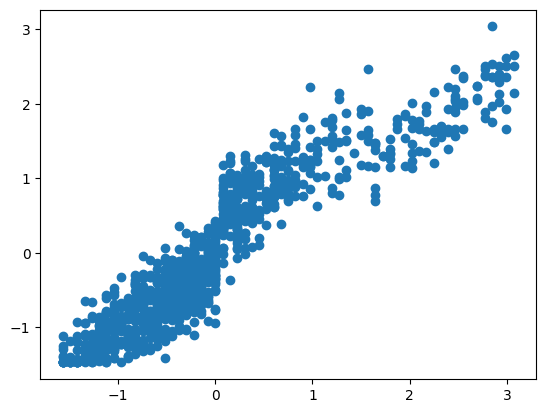

In [9]:
plt.scatter(X_scaled[:,0], X_scaled[:,1])

In [12]:
x.isnull().sum()

,0
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [13]:
x = x.fillna(x.mean())

In [15]:
X_scaled = StandardScaler().fit_transform(x)

In [16]:
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled)

df['Cluster'] = labels

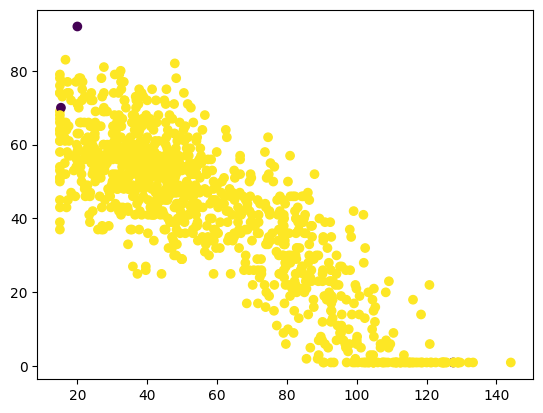

In [19]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])

In [20]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
labels = clusterer.fit_predict(X_scaled)

df['Cluster'] = labels

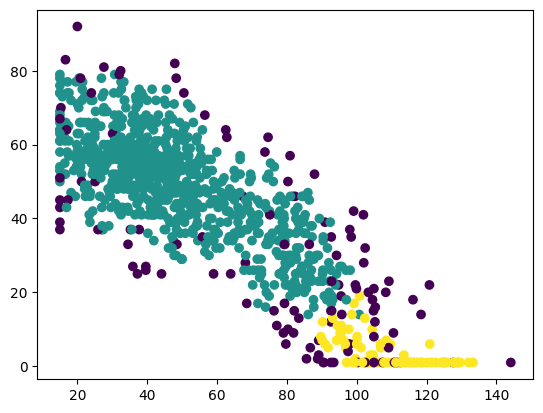

In [21]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])